## Train File

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_train = pd.read_csv("../data/processed/01.2/train_data.csv")

In [3]:
missing_data = df_train.isnull().sum()[df_train.isnull().sum() > 0].sort_values(ascending=False)

print("--- Number of Null ---")
print(missing_data)

--- Number of Null ---
Precipitation(in)    1645148
Wind_Chill(F)        1482771
Wind_Speed(mph)       344794
Wind_Direction         33784
Visibility(mi)         32958
Weather_Condition      30777
Humidity(%)            29692
Temperature(F)         22357
dtype: int64


In [4]:
missing_percent = (df_train.isnull().sum() / len(df_train)) * 100
missing_df = missing_percent[missing_percent > 0].sort_values(ascending=False)

print("--- Percent of Null ---")
print(missing_df)

--- Percent of Null ---
Precipitation(in)    30.080825
Wind_Chill(F)        27.111831
Wind_Speed(mph)       6.304410
Wind_Direction        0.617726
Visibility(mi)        0.602623
Weather_Condition     0.562744
Humidity(%)           0.542905
Temperature(F)        0.408788
dtype: float64


#### Skewness

In [5]:
def skewed(df):
    feature_cols = df.columns
    for col in feature_cols:
        if df[col].dtype in ["int64", "float64"]:
            skew = df[col].skew()
            direction = "right (positive)" if skew > 0 else "left (negative)"
            if abs(skew) > 1:
                print(f"[SKEWED]     {col:<30} skew = {skew:+.3f}  →  highly skewed {direction}")
            elif abs(skew) > 0.5:
                print(f"[MODERATE]   {col:<30} skew = {skew:+.3f}  →  moderately skewed {direction}")
            else:
                print(f"[NORMAL]     {col:<30} skew = {skew:+.3f}  →  approximately symmetric")

skewed(df_train)

[SKEWED]     Severity                       skew = +1.642  →  highly skewed right (positive)
[NORMAL]     Start_Lat                      skew = -0.057  →  approximately symmetric
[NORMAL]     Start_Lng                      skew = -0.482  →  approximately symmetric
[SKEWED]     Distance(mi)                   skew = +6.859  →  highly skewed right (positive)
[MODERATE]   Temperature(F)                 skew = -0.507  →  moderately skewed left (negative)
[MODERATE]   Wind_Chill(F)                  skew = -0.650  →  moderately skewed left (negative)
[NORMAL]     Humidity(%)                    skew = -0.405  →  approximately symmetric
[SKEWED]     Pressure(in)                   skew = -3.822  →  highly skewed left (negative)
[SKEWED]     Visibility(mi)                 skew = -1.186  →  highly skewed left (negative)
[MODERATE]   Wind_Speed(mph)                skew = +0.731  →  moderately skewed right (positive)
[SKEWED]     Precipitation(in)              skew = +10.098  →  highly skewed right 

In [6]:
def auto_transform_skewness(df):
    df_copy = df.copy()

    feature_cols = df_copy.select_dtypes(include=['int64', 'float64']).columns
    
    for col in feature_cols:
        if col != "Severity":
            skew = df_copy[col].skew()
            
            # Right skewed
            if skew > 1.0:
                if df_copy[col].min() >= 0:
                    df_copy[col] = np.log1p(df_copy[col])
            elif skew > 0.5:
                if df_copy[col].min() >= 0:
                    df_copy[col] = np.sqrt(df_copy[col])
                
            # Left skewed
            elif skew < -0.5:
                df_copy[col] = np.square(df_copy[col])
    return df_copy

In [7]:
df_transform = auto_transform_skewness(df_train)

In [8]:
skewed(df_transform)

[SKEWED]     Severity                       skew = +1.642  →  highly skewed right (positive)
[NORMAL]     Start_Lat                      skew = -0.057  →  approximately symmetric
[NORMAL]     Start_Lng                      skew = -0.482  →  approximately symmetric
[SKEWED]     Distance(mi)                   skew = +2.513  →  highly skewed right (positive)
[NORMAL]     Temperature(F)                 skew = +0.248  →  approximately symmetric
[NORMAL]     Wind_Chill(F)                  skew = +0.237  →  approximately symmetric
[NORMAL]     Humidity(%)                    skew = -0.405  →  approximately symmetric
[SKEWED]     Pressure(in)                   skew = -3.455  →  highly skewed left (negative)
[SKEWED]     Visibility(mi)                 skew = +8.768  →  highly skewed right (positive)
[MODERATE]   Wind_Speed(mph)                skew = -0.771  →  moderately skewed left (negative)
[SKEWED]     Precipitation(in)              skew = +8.824  →  highly skewed right (positive)
[MODERATE]

Weather Condition

In [9]:
df_transform["Weather_Condition"].unique()

array(['Overcast', 'Fair', 'Clear', 'Mostly Cloudy', 'Partly Cloudy',
       'Thunder', 'Thunderstorm', 'Light Rain', 'Cloudy',
       'Light Rain with Thunder', 'Fog', 'Light Snow', 'Scattered Clouds',
       'Light Drizzle', 'N/A Precipitation', 'Haze', nan,
       'Thunder in the Vicinity', 'Snow', 'Fair / Windy', 'Drizzle',
       'Rain', 'Heavy Rain', 'Light Thunderstorms and Rain',
       'Light Rain / Windy', 'Mostly Cloudy / Windy', 'Cloudy / Windy',
       'Heavy Snow / Windy', 'Heavy Rain / Windy', 'Wintry Mix',
       'Patches of Fog', 'Mist', 'Shallow Fog', 'Heavy Snow', 'T-Storm',
       'Smoke', 'Rain / Windy', 'Blowing Snow', 'Snow / Windy',
       'Light Snow / Windy', 'Fog / Windy', 'Partly Cloudy / Windy',
       'Light Freezing Rain', 'Heavy T-Storm',
       'Heavy Thunderstorms and Rain', 'Thunderstorms and Rain',
       'Blowing Dust', 'Wintry Mix / Windy', 'Light Freezing Fog',
       'Showers in the Vicinity', 'Haze / Windy',
       'Light Freezing Drizzle', 'Thu

In [10]:
df_transform['Weather_Condition'] = df_transform['Weather_Condition'].str.lower()

In [11]:
df_transform["Start_Time"] = pd.to_datetime(df_transform["Start_Time"], errors="coerce")
df_transform['Start_Date'] = df_transform['Start_Time'].dt.date
df_transform['Hour'] = df_transform['Start_Time'].dt.hour
df_transform['Month'] = df_transform['Start_Time'].dt.month

In [12]:
weather_first = df_transform.groupby(['City', 'Start_Date', 'Hour'])['Weather_Condition'].transform('first')
df_transform['Weather_Condition'] = df_transform['Weather_Condition'].fillna(weather_first)

In [13]:
missing_percent = (df_transform.isnull().sum() / len(df_transform)) * 100
missing_df = missing_percent[missing_percent > 0].sort_values(ascending=False)

print("--- Percent of Null ---")
print(missing_df)

--- Percent of Null ---
Precipitation(in)    30.080825
Wind_Chill(F)        27.111831
Wind_Speed(mph)       6.304410
Wind_Direction        0.617726
Visibility(mi)        0.602623
Humidity(%)           0.542905
Weather_Condition     0.506519
Temperature(F)        0.408788
dtype: float64


Solution 1

In [14]:
import numpy as np

conditions = [
    # 1. ระดับวิกฤต
    df_transform['Weather_Condition'].str.contains('thunder|storm|tornado|gale', na=False),
    
    # 2. ถนนลื่นอันตรายมาก
    df_transform['Weather_Condition'].str.contains('snow|sleet|ice|freez', na=False),
    
    # 3. ทัศนวิสัยแย่มาก 
    df_transform['Weather_Condition'].str.contains('fog|haze|smoke|dust', na=False),
    
    # 4. ถนนลื่นปกติ
    df_transform['Weather_Condition'].str.contains('rain|drizzle|shower', na=False),
    
    # 5. ลมแรง
    df_transform['Weather_Condition'].str.contains('wind|breezy|blustery|gusty', na=False),
    
    # 6. ท้องฟ้ามืดครึ้ม
    df_transform['Weather_Condition'].str.contains('cloud|overcast', na=False),
    
    # 7. ท้องฟ้าแจ่มใส
    df_transform['Weather_Condition'].str.contains('clear|fair', na=False)
]

choices = [
    'Severe',   # 1
    'Snow_Ice', # 2
    'Fog',      # 3
    'Rain',     # 4
    'Windy',    # 5
    'Cloudy',   # 6
    'Clear'     # 7
]

df_transform['Weather_Group'] = np.select(conditions, choices, default='Other')

df_transform = df_transform.drop(columns=['Weather_Condition'])

In [15]:
print(df_transform["Weather_Group"].value_counts())

Weather_Group
Clear       2399415
Cloudy      2282443
Rain         371351
Fog          144237
Snow_Ice     115511
Severe        61735
Windy         54216
Other         40184
Name: count, dtype: int64


In [16]:
mask_other = df_transform["Weather_Group"].isin(["Other", np.nan])

conditions_from_numbers = [
    (((df_transform['Wind_Speed(mph)'].notnull()) & (df_transform['Wind_Speed(mph)'] > 40)) | 
    ((df_transform['Precipitation(in)'].notnull()) & (df_transform['Precipitation(in)'] > 1.0))),


    (df_transform['Precipitation(in)'].notnull()) & (df_transform['Temperature(F)'].notnull()) & 
    (df_transform['Precipitation(in)'] > 0) & (df_transform['Temperature(F)'] < 32),
    
    (df_transform['Precipitation(in)'].notnull()) & (df_transform['Temperature(F)'].notnull()) & 
    (df_transform['Precipitation(in)'] > 0) & (df_transform['Temperature(F)'] >= 32),
    
    (df_transform['Visibility(mi)'].notnull()) & 
    (df_transform['Visibility(mi)'] < 2.0),
    
    (df_transform['Wind_Speed(mph)'].notnull()) & 
    (df_transform['Wind_Speed(mph)'] > 20),
    
    (df_transform['Humidity(%)'].notnull()) & 
    (df_transform['Humidity(%)'] > 80),
    
    (df_transform['Temperature(F)'].notnull())
]

choices_for_numbers = [
    "Severe",  # 1
    "Snow_Ice",  # 2
    "Rain",  # 3
    "Fog",  # 4
    "Windy",  # 5
    "Cloudy",  # 6
    "Clear",  # 7
]

df_transform.loc[mask_other, "Weather_Group"] = np.select(
    [cond[mask_other] for cond in conditions_from_numbers],
    choices_for_numbers,
    default="Other",
)

print(df_transform["Weather_Group"].value_counts())

Weather_Group
Clear       2416961
Cloudy      2293142
Rain         376980
Fog          146758
Snow_Ice     115513
Severe        61735
Windy         54216
Other          3787
Name: count, dtype: int64


In [17]:
# Hierarchical Imputation
hierarchies = [
    ['City', 'Start_Date', 'Hour'],  
    ['City', 'Start_Date'],        
    ['City', 'Month'],           
    ['Weather_Group']            
]

num_weather_cols = [
    'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 
    'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', "Wind_Direction"
]

print("เริ่มกระบวนการ Hierarchical Imputation...")

for col in num_weather_cols:
    
    for group_cols in hierarchies:

        if df_transform[col].isnull().sum() == 0:
            break
        
        if df_transform[col].dtype != "object":
            df_transform[col] = df_transform[col].fillna(
                df_transform.groupby(group_cols)[col].transform('mean')
            )
        else:
            df_transform[col] = df_transform[col].fillna(
                df_transform.groupby(group_cols)[col].transform('first')
            )

เริ่มกระบวนการ Hierarchical Imputation...


In [18]:
missing_percent = (df_transform.isnull().sum() / len(df_transform)) * 100
missing_df = missing_percent[missing_percent > 0].sort_values(ascending=False)

print("--- Percent of Null ---")
print(missing_df)

--- Percent of Null ---
Series([], dtype: float64)


Solution 2

In [19]:
# df_adv_clean['is_Rain'] = df_adv_clean['Weather_Condition'].str.contains('rain|drizzle|shower', na=False).astype(int)
# df_adv_clean['is_Snow'] = df_adv_clean['Weather_Condition'].str.contains('snow|sleet|ice|freez', na=False).astype(int)
# df_adv_clean['is_Fog'] = df_adv_clean['Weather_Condition'].str.contains('fog|haze|smoke|dust', na=False).astype(int)
# df_adv_clean['is_Severe'] = df_adv_clean['Weather_Condition'].str.contains('thunder|storm|tornado', na=False).astype(int)
# df_adv_clean['is_Cloudy'] = df_adv_clean['Weather_Condition'].str.contains('cloud|overcast', na=False).astype(int)
# df_adv_clean['is_Windy'] = df_adv_clean['Weather_Condition'].str.contains('wind|breezy|blustery|gusty', na=False).astype(int)

# df_adv_clean = df_adv_clean.drop(columns=['Weather_Condition'])

array([[<Axes: title={'center': 'Severity'}>,
        <Axes: title={'center': 'Start_Time'}>,
        <Axes: title={'center': 'Start_Lat'}>,
        <Axes: title={'center': 'Start_Lng'}>],
       [<Axes: title={'center': 'Distance(mi)'}>,
        <Axes: title={'center': 'Temperature(F)'}>,
        <Axes: title={'center': 'Wind_Chill(F)'}>,
        <Axes: title={'center': 'Humidity(%)'}>],
       [<Axes: title={'center': 'Pressure(in)'}>,
        <Axes: title={'center': 'Visibility(mi)'}>,
        <Axes: title={'center': 'Wind_Speed(mph)'}>,
        <Axes: title={'center': 'Precipitation(in)'}>],
       [<Axes: title={'center': 'Duration(min)'}>,
        <Axes: title={'center': 'Hour'}>,
        <Axes: title={'center': 'Month'}>, <Axes: >]], dtype=object)

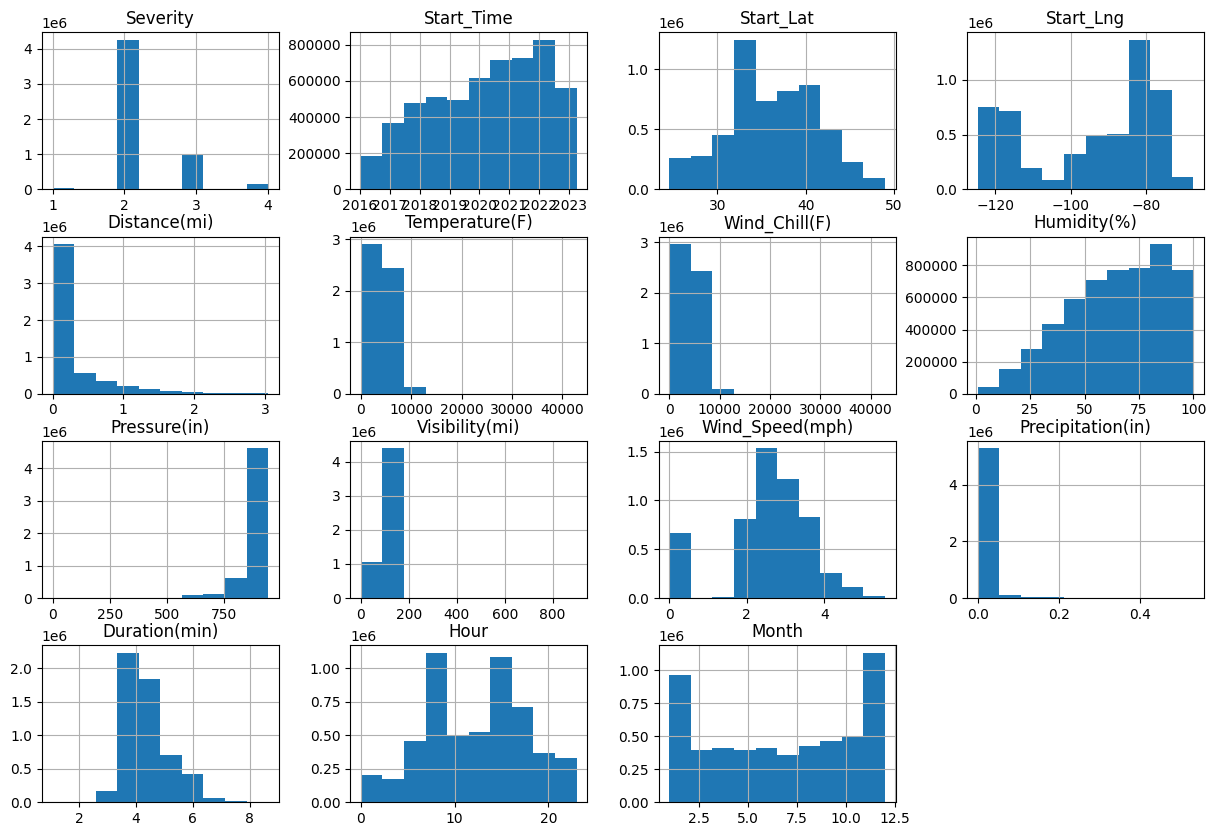

In [20]:
df_transform.hist(figsize=(15, 10))

In [21]:
skewed(df_transform)

[SKEWED]     Severity                       skew = +1.642  →  highly skewed right (positive)
[NORMAL]     Start_Lat                      skew = -0.057  →  approximately symmetric
[NORMAL]     Start_Lng                      skew = -0.482  →  approximately symmetric
[SKEWED]     Distance(mi)                   skew = +2.513  →  highly skewed right (positive)
[NORMAL]     Temperature(F)                 skew = +0.246  →  approximately symmetric
[NORMAL]     Wind_Chill(F)                  skew = +0.128  →  approximately symmetric
[NORMAL]     Humidity(%)                    skew = -0.406  →  approximately symmetric
[SKEWED]     Pressure(in)                   skew = -3.455  →  highly skewed left (negative)
[SKEWED]     Visibility(mi)                 skew = +8.775  →  highly skewed right (positive)
[MODERATE]   Wind_Speed(mph)                skew = -0.762  →  moderately skewed left (negative)
[SKEWED]     Precipitation(in)              skew = +9.198  →  highly skewed right (positive)
[MODERATE]

In [22]:
save_dir = "../data/processed/01.3"

df_transform.to_csv(f"{save_dir}/accidents_advance_clean.csv", index=False)

print(f"Number of df_adv_clean rows: {df_transform.shape[0]:,} rows")

Number of df_adv_clean rows: 5,469,092 rows
